In [ ]:
!wget -O names.txt https://raw.githubusercontent.com/karpathy/makemore/master/names.txt

--2026-06-29 01:22:42--  https://raw.githubusercontent.com/karpathy/makemore/master/names.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 228145 (223K) [text/plain]
Saving to: ‘names.txt’

names.txt           100%[===================>] 222.80K  --.-KB/s    in 0.02s   

2026-06-29 01:22:43 (11.4 MB/s) - ‘names.txt’ saved [228145/228145]



In [ ]:
words = open("names.txt", "r").read().splitlines()

In [ ]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
 chars = sorted(list(set(''.join(words))))
 stoi = {s:i+1 for i,s in enumerate(chars)}
 stoi['.'] = 0
 itos = {i:s for s, i in stoi.items()}


In [ ]:
# building the dataset

block_size = 3
X, Y = [], []
for w in words:
  # print(w)
  context = [0]*block_size
  for ch in w+'.':
    ix = stoi[ch]
    X.append(context)
    Y.append(ix)
    # print(''.join(itos[i] for i in context), '--->', itos[ix])
    context = context[1:]+[ix]

X = torch.tensor(X)
Y = torch.tensor(Y)

In [ ]:
def build_dataset(words):
  block_size = 3
  X, Y = [], []
  for w in words:
    # print(w)
    context = [0]*block_size
    for ch in w+'.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      # print(''.join(itos[i] for i in context), '--->', itos[ix])
      context = context[1:]+[ix]

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  return X,Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1]) # training set
Xdev, Ydev = build_dataset(words[n1:n2]) # dev set
Xte, Yte = build_dataset(words[n2:]) # testing set

In [ ]:
X.shape

torch.Size([228146, 3])

In [ ]:
Y

tensor([ 5, 13, 13,  ..., 26, 24,  0])

In [ ]:
C = torch.randn((27,2))

In [ ]:
Y[13]

tensor(22)

In [ ]:
X[13]

tensor([0, 0, 1])

In [ ]:
C[X].shape  # (batch_size, block_size, embedding_dim)

torch.Size([228146, 3, 2])

In [ ]:
emb = C[X]
emb.shape

torch.Size([228146, 3, 2])

In [ ]:
W1 = torch.randn((6,100))
b1 = torch.rand(100)

In [ ]:
# emb.view(32,6) @ W1 + b1 #  dimensioons mismatch
# h = torch.tanh(emb.view(32,6) @ W1 + b1)
# h

In [ ]:
# method 1
# torch.cat([emb[:,0,:], emb[:,1,:], emb[:,2,:]],1).shape

In [ ]:
# method 2
# torch.cat(torch.unbind(emb,1),1).shape

In [ ]:
# method 3 and best one ()
# emb.view(32,6).shape

In [ ]:
b1

tensor([0.9672, 0.2330, 0.0584, 0.6778, 0.3601, 0.3381, 0.3419, 0.3757, 0.4138,
        0.2179, 0.7674, 0.0665, 0.1680, 0.9835, 0.3015, 0.0362, 0.2286, 0.8444,
        0.5857, 0.9241, 0.5015, 0.3816, 0.6417, 0.4816, 0.0075, 0.3204, 0.9644,
        0.9176, 0.9312, 0.8803, 0.5638, 0.7562, 0.0092, 0.8261, 0.9279, 0.9666,
        0.2208, 0.8822, 0.8268, 0.8677, 0.4368, 0.6117, 0.7132, 0.8609, 0.4622,
        0.8762, 0.2265, 0.3886, 0.8571, 0.6849, 0.1998, 0.2149, 0.2034, 0.6810,
        0.8602, 0.9504, 0.1832, 0.7956, 0.0039, 0.5687, 0.9652, 0.1915, 0.7205,
        0.1130, 0.5595, 0.3551, 0.1159, 0.3966, 0.3850, 0.4407, 0.3258, 0.5144,
        0.2356, 0.4579, 0.0942, 0.3170, 0.0093, 0.4163, 0.8306, 0.5575, 0.9254,
        0.0485, 0.0066, 0.6473, 0.3856, 0.7873, 0.6374, 0.9676, 0.1525, 0.8078,
        0.4036, 0.5713, 0.0288, 0.8963, 0.3284, 0.6011, 0.7360, 0.3167, 0.7883,
        0.5907])

In [ ]:
lr = torch.linspace(0.001,1,1000) #learning rate
lre = torch.linspace(-3,0,1000) #learning rate exponent
lrs = 10**lre # actual learning rates

In [ ]:
# Everyhting all together
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27,2), generator = g)
W1 = torch.randn((6,300), generator = g)
b1 = torch.randn(300, generator = g)
W2 = torch.randn((300,27), generator = g)
b2 = torch.randn(27, generator = g)
parameters = [C, W1, b1, W2, b2]
for p in parameters:
  p.requires_grad = True
sum(p.nelement() for p in parameters)

10281

In [ ]:
lri = []
lossi = []
stepi = []
for i in range(100000):

  # mini batch
  ix = torch.randint(0,Xtr.shape[0],(32,))
  #forward pass
  emb  = C[Xtr[ix]] #(32,3,2)
  h = torch.tanh(emb.view(-1,6) @ W1 + b1) #(32,100)
  logits = h @ W2 + b2 #(32,27)
  # counts = logits.exp()
  # prob = counts/counts.sum(1, keepdims = True)
  # loss = - prob[torch.arange(32),Y].log().mean()
  # replacign above by cross_entropy as
  loss = F.cross_entropy(logits,Ytr[ix])

  # backward pass
  for p in parameters:
    p.grad = None

  loss.backward()

  # nudge the weights such that we are minimizing the loss or going in negative gradient direction hehe
  # lr = lrs[i]
  lr = 0.1 if i<10000 else 0.01 # we found form the graph the optimal learning rate
  for p in parameters:
    p.data += -1 * lr * p.grad

  stepi.append(i)
  # lri.append(lre[i])
  lossi.append(loss.item())
print(loss.item())

2.2966055870056152


In [ ]:
emb  = C[Xdev] #(32,3,2)
h = torch.tanh(emb.view(-1,6) @ W1 + b1) #(32,100)
logits = h @ W2 + b2 #(32,27)
loss = F.cross_entropy(logits,Ydev)
loss.item()

2.292395830154419

In [ ]:
emb  = C[Xdev] #(32,3,2)
h = torch.tanh(emb.view(-1,6) @ W1 + b1) #(32,100)
logits = h @ W2 + b2 #(32,27)
loss = F.cross_entropy(logits,Ydev)
loss.item()

2.292395830154419

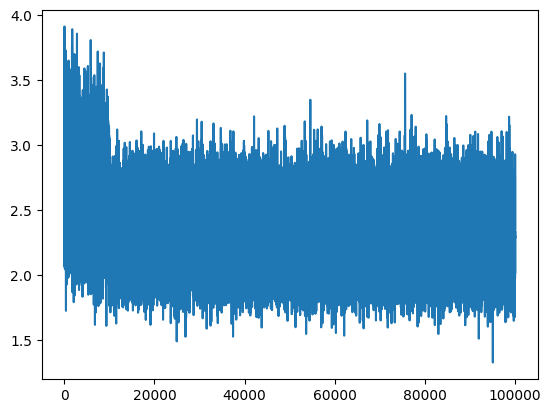

In [ ]:
plt.plot(stepi,lossi)

In [ ]:
sum(p.nelement() for p in parameters)

10281

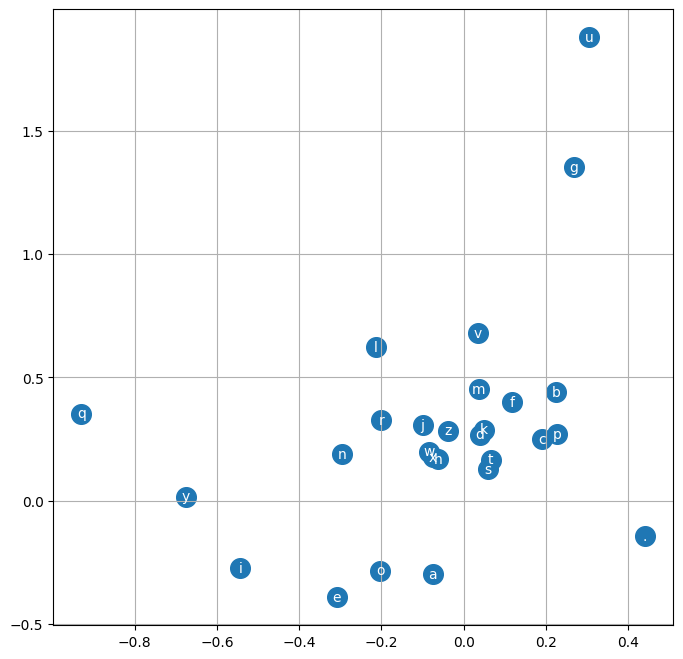

In [ ]:
# visualize dimensions 0 and 1 of the embedding matrix C for all characters
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color='white')
plt.grid('minor')

In [ ]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):

    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      emb = C[torch.tensor([context])] # (1,block_size,d)
      h = torch.tanh(emb.view(1, -1) @ W1 + b1)
      logits = h @ W2 + b2
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break

    print(''.join(itos[i] for i in out))

ssspasspasspasspasspasspasspastpewqbewszewqbewqbewszeaszepwqbewqbewszeaszeaszepwqbewszeaszeaszepwqbewqbewqbewszepwqbewqbewszepwqbewszeaszeaszepwqbewszepwqbewszeaszepwqbewszepwqbewszeaszepwqbewqbewszeaszeaszeaszeaszeaszeaszepwqbewszlwqbewqbewqbewszepwqbewqbewszepwqbewszepwqbewqbewszlwqbewqbewqbewszlwqbewszeaszepwqbewszepwqbewszlwqbewszeaszeaszepwqbewszepwqbewqbewqbewszepwqbewqbewszepwqbewqbewszlwqbewszeaszeaszeaszeaszepwqbewqbewqbewszewqbewqbewszepwqbewszeasspastpefitlvlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwlwl